# Postprocess Diagnostics (Backdoor CATE)


In [1]:
import os
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [2]:

import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def load_summary(path):
    rows = []
    with open(path, newline='', encoding='utf-8-sig') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
    return rows


def as_float(x):
    try:
        return float(x)
    except Exception:
        return float('nan')


def summarize_rows(rows, n=5):
    print(f'Total rows: {len(rows)}')
    for r in rows[:n]:
        print({k: r.get(k) for k in ['run_id','method','dgp','rep','run_seed','status','artifacts_dir']})


def filter_rows_with_artifacts(rows):
    return [r for r in rows if r.get('artifacts_dir')]


def normalize_artifacts_dir(artifacts_dir):
    p = Path(artifacts_dir)
    if p.exists():
        return str(p)
    s = str(p).replace('\\', '/')
    linux_root = '/home/javureke/projects/Generalized-Bayes-for-CI'
    if s.startswith(linux_root):
        candidate = Path(s.replace(linux_root, str(Path.cwd())))
        if candidate.exists():
            return str(candidate)
    marker = '/results/'
    if marker in s:
        suffix = s.split(marker, 1)[1]
        candidate = Path.cwd() / 'results' / suffix
        if candidate.exists():
            return str(candidate)
    return str(p)


def load_artifacts(artifacts_dir):
    artifacts_dir = normalize_artifacts_dir(artifacts_dir)
    arrays_path = os.path.join(artifacts_dir, 'arrays.npz')
    run_cfg_path = os.path.join(artifacts_dir, 'run_config.json')
    history_path = os.path.join(artifacts_dir, 'history.json')
    arrays = dict(np.load(arrays_path)) if os.path.exists(arrays_path) else {}
    run_cfg = None
    history = None
    if os.path.exists(run_cfg_path):
        import json
        with open(run_cfg_path, 'r', encoding='utf-8-sig') as f:
            run_cfg = json.load(f)
    if os.path.exists(history_path):
        import json
        with open(history_path, 'r', encoding='utf-8-sig') as f:
            history = json.load(f)
    return arrays, run_cfg, history


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1.0 - ss_res / ss_tot


def nuisance_diagnostics(e_hat, mu0_hat, mu1_hat, Y, A):
    a1 = e_hat[A == 1]
    a0 = e_hat[A == 0]
    if len(a1) > 0 and len(a0) > 0:
        auc_like = np.mean(a1[:, None] > a0[None, :])
    else:
        auc_like = np.nan
    mse0 = np.mean((Y[A == 0] - mu0_hat[A == 0]) ** 2) if np.any(A == 0) else np.nan
    mse1 = np.mean((Y[A == 1] - mu1_hat[A == 1]) ** 2) if np.any(A == 1) else np.nan
    r2_0 = r2_score(Y[A == 0], mu0_hat[A == 0]) if np.any(A == 0) else np.nan
    r2_1 = r2_score(Y[A == 1], mu1_hat[A == 1]) if np.any(A == 1) else np.nan
    overlap = np.mean((e_hat > 0.05) & (e_hat < 0.95))
    print(f'MSE(mu0): {mse0:.3f}, MSE(mu1): {mse1:.3f}')
    print(f'R2(mu0): {r2_0:.3f}, R2(mu1): {r2_1:.3f}')
    print(f'Propensity mean: {e_hat.mean():.3f}, std: {e_hat.std():.3f}, AUC~={auc_like:.3f}, overlap: {overlap:.3f}')

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    bins = np.linspace(0, 1, 25)
    axs[0, 0].hist(e_hat[A == 0], bins=bins, alpha=0.6, label='A=0')
    axs[0, 0].hist(e_hat[A == 1], bins=bins, alpha=0.6, label='A=1')
    axs[0, 0].set_title(f'Propensity histograms (AUC~={auc_like:.2f})')
    axs[0, 0].set_xlabel('e_hat')
    axs[0, 0].legend()

    axs[0, 1].scatter(mu0_hat[A == 0], Y[A == 0], s=8, alpha=0.5, color='C0')
    lo, hi = np.percentile(Y, [1, 99])
    axs[0, 1].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axs[0, 1].set_title('mu0_hat vs. Y (A=0)')
    axs[0, 1].set_xlabel('mu0_hat')
    axs[0, 1].set_ylabel('Y')

    axs[1, 1].scatter(mu1_hat[A == 1], Y[A == 1], s=8, alpha=0.5, color='C1')
    axs[1, 1].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axs[1, 1].set_title('mu1_hat vs. Y (A=1)')
    axs[1, 1].set_xlabel('mu1_hat')
    axs[1, 1].set_ylabel('Y')

    res0 = Y[A == 0] - mu0_hat[A == 0]
    res1 = Y[A == 1] - mu1_hat[A == 1]
    axs[1, 0].scatter(mu0_hat[A == 0], res0, s=8, alpha=0.5, color='C0', label='A=0')
    axs[1, 0].scatter(mu1_hat[A == 1], res1, s=8, alpha=0.5, color='C1', label='A=1')
    axs[1, 0].axhline(0.0, color='k', linestyle='--', lw=1)
    axs[1, 0].set_title('Residuals vs fitted')
    axs[1, 0].set_xlabel('mu_hat')
    axs[1, 0].set_ylabel('Y - mu_hat')
    axs[1, 0].legend()

    plt.tight_layout()
    plt.show()


def gbi_cate_diagnostics(history):
    if not history:
        print('No history found.')
        return
    steps = [h.get('step') for h in history]
    objective = [h.get('objective') for h in history]
    data_term = [h.get('data_term') for h in history]
    kl_term = [h.get('kl_term') for h in history]

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(steps, objective)
    axs[0].set_title('CATE GBI objective')
    axs[0].set_xlabel('Step')
    axs[0].set_ylabel('Objective')
    axs[0].set_yscale('log')

    axs[1].plot(steps, data_term, label='data_term')
    axs[1].plot(steps, kl_term, label='kl_term')
    axs[1].plot(steps, objective, label='objective')
    axs[1].set_title('Objective components')
    axs[1].set_xlabel('Step')
    axs[1].set_ylabel('Value')
    axs[1].set_yscale('log')
    axs[1].legend()

    plt.tight_layout()
    plt.show()


In [3]:

# experiment_id = 'exp1_backdoor_cate_attempt_1'
# experiment_id = 'exp1_backdoor_cate_attempt_2_TEST'
experiment_id = 'exp1_backdoor_cate_attempt_1'

results_root = 'results'
summary_path = os.path.join(results_root, experiment_id, 'summary.csv')

rows = load_summary(summary_path)
summarize_rows(rows)

rows_with_artifacts = filter_rows_with_artifacts(rows)
print(f'Rows with artifacts: {len(rows_with_artifacts)}')

summarize_rows(rows_with_artifacts, n=10)


Total rows: 1350
{'run_id': 'run_d91a52e15f72', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '0', 'run_seed': '2774624636', 'status': 'ok', 'artifacts_dir': 'C:\\Users\\javurek\\Desktop\\Generalised Bayes\\results\\exp1_backdoor_cate_attempt_1\\artifacts\\run_d91a52e15f72'}
{'run_id': 'run_b392972d0506', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '1', 'run_seed': '2487898314', 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_987908f7c600', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '2', 'run_seed': '2725036156', 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_cf1a5fa3d58a', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '3', 'run_seed': '334788847', 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_cb779e96cebe', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '4', 'run_seed': '2557231585', 'status': 'ok', 'artifacts_dir': ''}
Rows with artifacts: 27
Total rows: 27
{'run_id': 'run_d91a52e15f72', 'method': 'aipw', 'dgp': 'dgp_1', 'rep': '0', 'run_seed': '2774624636', 'status': 'ok', 'artifacts_d

In [18]:

# Choose a run_id from the summary to inspect (prefer one with artifacts_dir)
row_n = 9 #21
run_id = rows_with_artifacts[row_n]['run_id']
artifacts_dir = rows_with_artifacts[row_n]['artifacts_dir']

arrays, run_cfg, history = load_artifacts(artifacts_dir)

if not arrays:
    raise FileNotFoundError(f'No arrays.npz found in {artifacts_dir}')

# Pull arrays
cate_X_eval = arrays.get('cate_X_eval')
cate_true = arrays.get('cate_true')
cate_mean_vi = arrays.get('cate_mean_vi')
cate_mean_analytic = arrays.get('cate_mean_analytic')

# Optional variance arrays
cate_var_vi = arrays.get('cate_var_vi')
cate_var_analytic = arrays.get('cate_var_analytic')

# Pseudo-outcomes
phi = arrays.get('phi')

# Nuisance arrays
e_hat = arrays.get('e_hat')
mu0_hat = arrays.get('mu0_hat')
mu1_hat = arrays.get('mu1_hat')

print('Run config:', run_cfg['data'],run_cfg['loss']["phi_fn_REGISTRATION"] if run_cfg else None)


Run config: {'data_kind': 'backdoor_cate', 'dgp_fn_REGISTRATION': 'dgp_4', 'dgp_kwargs': {}, 'n': 1000} aipw


MSE(mu0): 0.918, MSE(mu1): 1.092
R2(mu0): 0.643, R2(mu1): 0.785
Propensity mean: 0.488, std: 0.176, AUC~=0.688, overlap: 0.994


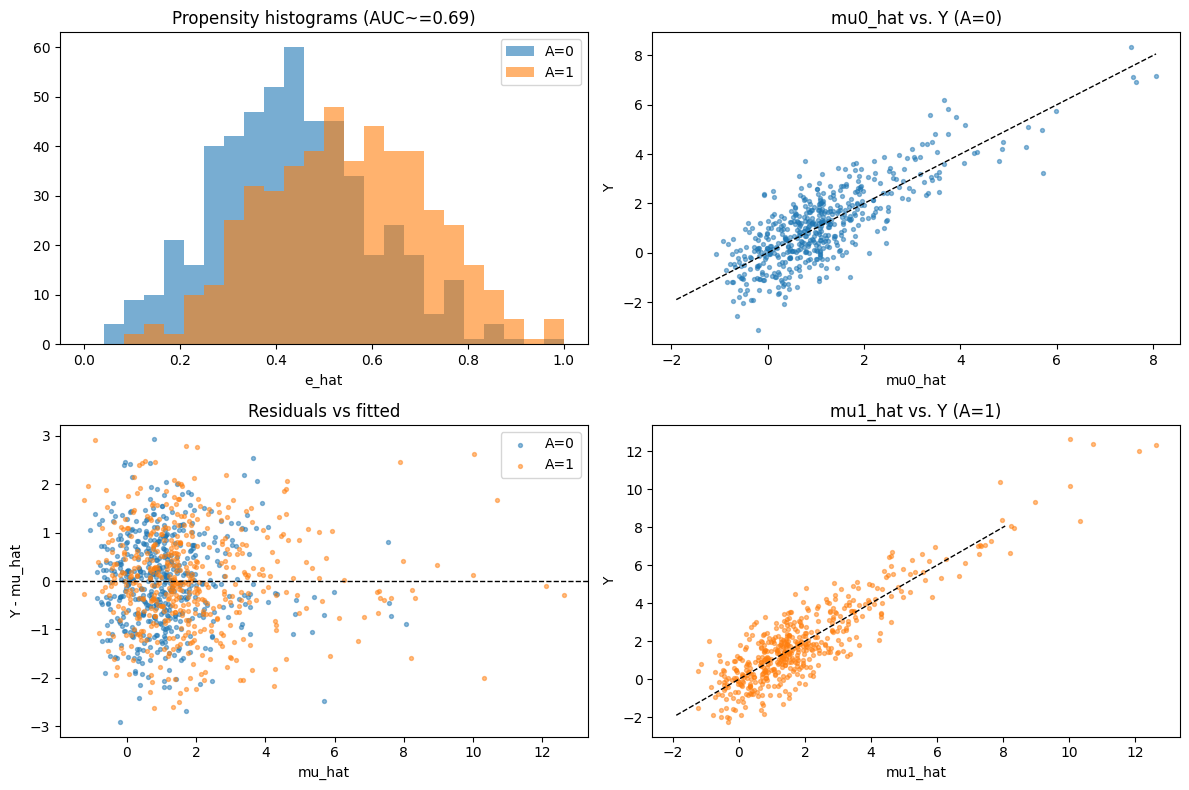

In [19]:

# Re-simulate data using src.py to get X, A, Y for nuisance diagnostics
import importlib.util
import pathlib

src_path = pathlib.Path('src.py').resolve()
spec = importlib.util.spec_from_file_location('src', src_path)
src = importlib.util.module_from_spec(spec)
spec.loader.exec_module(src)

dgp_name = run_cfg['data']['dgp_fn_REGISTRATION']
data_cfg = run_cfg.get('data', {})
misc_cfg = run_cfg.get('misc', {})
run_seed = misc_cfg.get('run_seed')
run_seed = int(run_seed) if run_seed is not None else None
if run_seed is not None:
    seed = src.build_run_seeds(run_seed)['dgp']
else:
    seed = data_cfg.get('seed', None)
    seed = int(seed) if seed is not None else None
n = int(data_cfg['n'])
dgp_kwargs = data_cfg.get('dgp_kwargs', {})

dgp_fn = src._resolve_from_registry(dgp_name, src._DGP_REGISTRY, 'dgp_fn_REGISTRATION')
if seed is None:
    data = dgp_fn(n=n, **dgp_kwargs)
else:
    data = dgp_fn(n=n, seed=seed, **dgp_kwargs)
A = data['A']
Y = data['Y']

if e_hat is not None and mu0_hat is not None and mu1_hat is not None:
    nuisance_diagnostics(e_hat, mu0_hat, mu1_hat, Y, A)


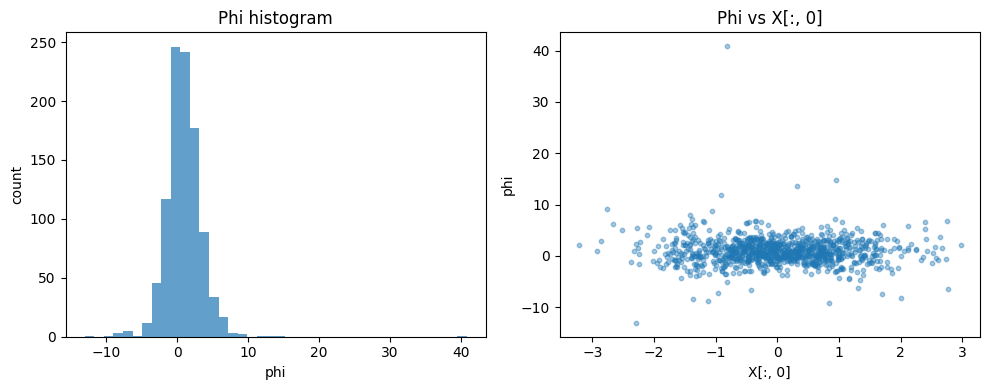

In [20]:

# Phi diagnostics
if phi is not None and 'X' in data:
    X = data['X']
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(phi, bins=40, alpha=0.7)
    plt.title('Phi histogram')
    plt.xlabel('phi')
    plt.ylabel('count')

    plt.subplot(1, 2, 2)
    if X.ndim == 2 and X.shape[1] >= 1:
        plt.scatter(X[:, 0], phi, s=10, alpha=0.4)
        plt.xlabel('X[:, 0]')
    else:
        plt.scatter(np.arange(len(phi)), phi, s=10, alpha=0.4)
        plt.xlabel('index')
    plt.ylabel('phi')
    plt.title('Phi vs X[:, 0]')
    plt.tight_layout()
    plt.show()


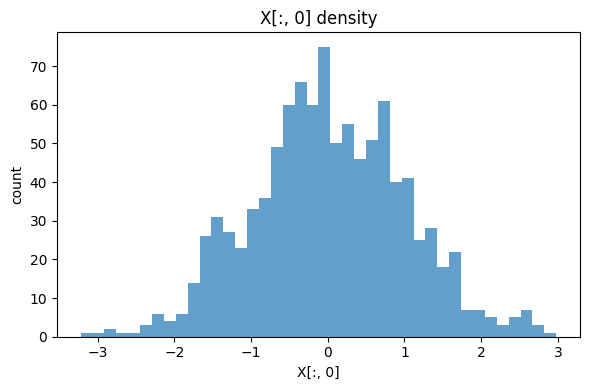

In [21]:

# Data density along X[:,0]
if 'X' in data:
    X = data['X']
    if X.ndim == 2 and X.shape[1] >= 1:
        plt.figure(figsize=(6, 4))
        plt.hist(X[:, 0], bins=40, alpha=0.7)
        plt.title('X[:, 0] density')
        plt.xlabel('X[:, 0]')
        plt.ylabel('count')
        plt.tight_layout()
        plt.show()


Analytic vs VI: RMSE=0.1632, MAE=0.1140


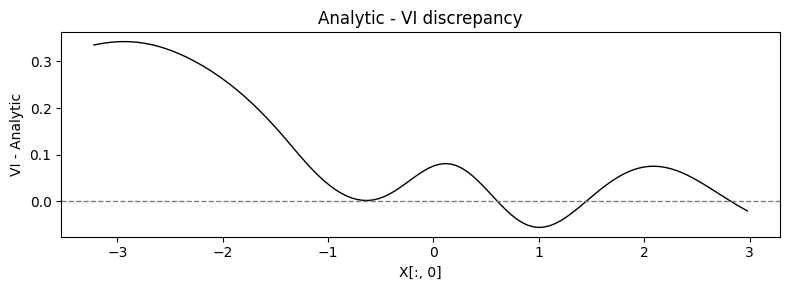

In [22]:

# Analytic vs VI discrepancy metrics
if cate_mean_vi is not None and cate_mean_analytic is not None:
    diff = cate_mean_vi - cate_mean_analytic
    rmse = np.sqrt(np.mean(diff ** 2))
    mae = np.mean(np.abs(diff))
    print(f'Analytic vs VI: RMSE={rmse:.4f}, MAE={mae:.4f}')

    if cate_X_eval is not None:
        X_eval = np.asarray(cate_X_eval)
        order = np.argsort(X_eval[:, 0]) if X_eval.ndim == 2 else np.arange(len(diff))
        plt.figure(figsize=(8, 3))
        plt.plot(X_eval[order, 0], diff[order], 'k-', lw=1)
        plt.axhline(0.0, color='gray', linestyle='--', lw=1)
        plt.title('Analytic - VI discrepancy')
        plt.xlabel('X[:, 0]')
        plt.ylabel('VI - Analytic')
        plt.tight_layout()
        plt.show()


In [23]:

# Tail vs center MSE (by quantiles of X_eval[:,0])
if cate_X_eval is not None and cate_true is not None:
    X_eval = np.asarray(cate_X_eval)
    if X_eval.ndim == 2 and X_eval.shape[1] >= 1:
        x0 = X_eval[:, 0]
        q_lo = np.quantile(x0, 0.1)
        q_hi = np.quantile(x0, 0.9)
        mask_tail = (x0 <= q_lo) | (x0 >= q_hi)
        mask_mid = (x0 > q_lo) & (x0 < q_hi)

        def _mse(pred):
            if pred is None:
                return np.nan, np.nan
            mse_tail = np.mean((pred[mask_tail] - cate_true[mask_tail]) ** 2)
            mse_mid = np.mean((pred[mask_mid] - cate_true[mask_mid]) ** 2)
            return mse_tail, mse_mid

        mse_tail_vi, mse_mid_vi = _mse(cate_mean_vi)
        mse_tail_an, mse_mid_an = _mse(cate_mean_analytic)
        print(f'MSE (VI) tails: {mse_tail_vi:.4f}, middle: {mse_mid_vi:.4f}')
        print(f'MSE (Analytic) tails: {mse_tail_an:.4f}, middle: {mse_mid_an:.4f}')


MSE (VI) tails: 0.3626, middle: 0.0817
MSE (Analytic) tails: 0.1308, middle: 0.0233


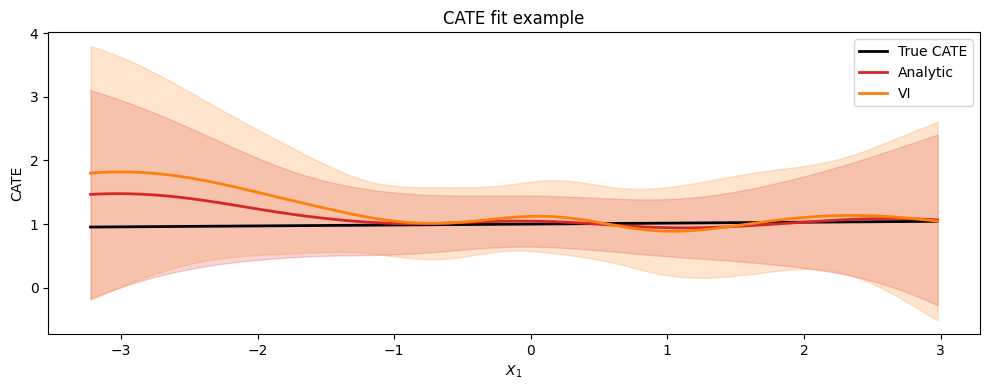

In [ ]:

# CATE diagnostics with uncertainty bands (if available)
if cate_X_eval is not None and cate_true is not None:
    X_eval = np.asarray(cate_X_eval)
    order = np.argsort(X_eval[:, 0]) if X_eval.ndim == 2 else np.arange(len(cate_true))
    
    plt.figure(figsize=(10, 4))
    # fig = plt.figure(figsize=(10, 4))
    plt.plot(X_eval[order, 0], np.asarray(cate_true)[order], 'k-', lw=2, label='True CATE')

    if cate_mean_analytic is not None:
        plt.plot(X_eval[order, 0], np.asarray(cate_mean_analytic)[order], 'C3-', lw=2, label='Analytic')
        if cate_var_analytic is not None:
            std = np.sqrt(np.maximum(cate_var_analytic, 1e-12))
            lo = (cate_mean_analytic - 2 * std)[order]
            hi = (cate_mean_analytic + 2 * std)[order]
            plt.fill_between(X_eval[order, 0], lo, hi, color='C3', alpha=0.2)

    if cate_mean_vi is not None:
        plt.plot(X_eval[order, 0], np.asarray(cate_mean_vi)[order], 'C1-', lw=2, label='VI')
        if cate_var_vi is not None:
            std = np.sqrt(np.maximum(cate_var_vi, 1e-12))
            lo = (cate_mean_vi - 2 * std)[order]
            hi = (cate_mean_vi + 2 * std)[order]
            plt.fill_between(X_eval[order, 0], lo, hi, color='C1', alpha=0.2)

    plt.xlabel('X[:, 0]')
    plt.ylabel('CATE')
    plt.title('CATE fit diagnostics (with uncertainty)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # plt.xlabel(r'$X_{1}$')
    # plt.ylabel('CATE')
    # plt.title('CATE fit example')
    # plt.legend()
    # plt.tight_layout()
    # plt.show()
    # fig.savefig('outputs/diagnostic_cate_fit_example.pdf', dpi=300)

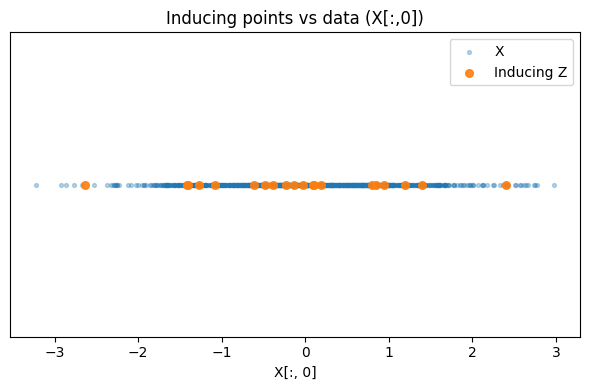

In [25]:

# Inducing point coverage (optional)
try:
    import torch
    import os
    q_state_path = os.path.join(artifacts_dir, 'q_family_state.pt')
    if os.path.exists(q_state_path) and run_cfg is not None:
        q_cfg = run_cfg.get('var_family', {})
        q_kwargs = q_cfg.get('q_family_kwargs', {})
        q_family = src.InducingPointGP(X_train=data['X'], device='cpu', **q_kwargs)
        q_family.load_state_dict(torch.load(q_state_path, map_location='cpu'))
        Z = q_family.Z.detach().cpu().numpy()
        if Z.ndim == 2 and Z.shape[1] >= 1:
            plt.figure(figsize=(6, 4))
            plt.scatter(data['X'][:, 0], np.zeros_like(data['X'][:, 0]), s=8, alpha=0.3, label='X')
            plt.scatter(Z[:, 0], np.zeros_like(Z[:, 0]), s=30, alpha=0.9, label='Inducing Z')
            plt.title('Inducing points vs data (X[:,0])')
            plt.xlabel('X[:, 0]')
            plt.yticks([])
            plt.legend()
            plt.tight_layout()
            plt.show()
except Exception as exc:
    print('Inducing point diagnostic skipped:', exc)


In [26]:

# Constant mean function example (center phi, fit GP on residuals, add mean back)
if phi is not None:
    phi_mean = float(np.mean(phi))
    phi_centered = phi - phi_mean
    print(f'Constant mean example: phi_mean={phi_mean:.4f}')
    print('To use this in the model, fit GP to phi_centered and add phi_mean to predictions.')


Constant mean example: phi_mean=0.9316
To use this in the model, fit GP to phi_centered and add phi_mean to predictions.


CATE MSE (VI): 0.1379
CATE MSE (Analytic): 0.0448


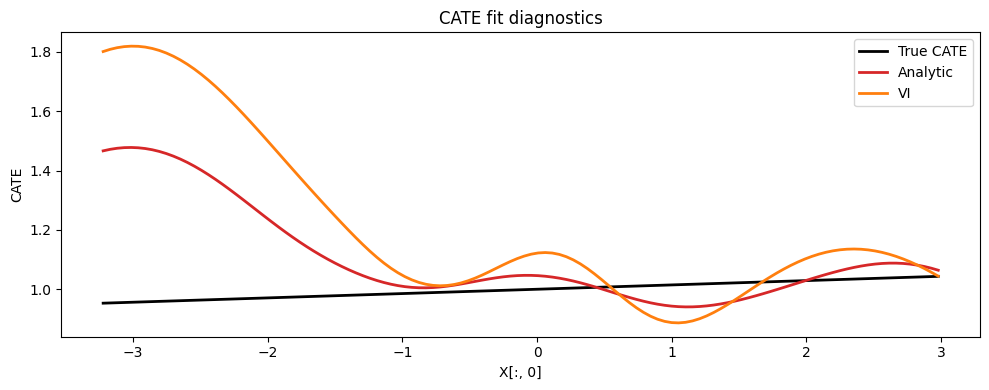

In [27]:

# CATE diagnostics
if cate_true is not None and cate_mean_vi is not None:
    mse_vi = np.mean((cate_mean_vi - cate_true) ** 2)
    print(f'CATE MSE (VI): {mse_vi:.4f}')
if cate_true is not None and cate_mean_analytic is not None:
    mse_an = np.mean((cate_mean_analytic - cate_true) ** 2)
    print(f'CATE MSE (Analytic): {mse_an:.4f}')

if cate_X_eval is not None and cate_true is not None:
    X_eval = np.asarray(cate_X_eval)
    order = np.argsort(X_eval[:, 0]) if X_eval.ndim == 2 else np.arange(len(cate_true))
    plt.figure(figsize=(10, 4))
    plt.plot(X_eval[order, 0], np.asarray(cate_true)[order], 'k-', lw=2, label='True CATE')
    if cate_mean_analytic is not None:
        plt.plot(X_eval[order, 0], np.asarray(cate_mean_analytic)[order], 'C3-', lw=2, label='Analytic')
    if cate_mean_vi is not None:
        plt.plot(X_eval[order, 0], np.asarray(cate_mean_vi)[order], 'C1-', lw=2, label='VI')
    plt.xlabel('X[:, 0]')
    plt.ylabel('CATE')
    plt.title('CATE fit diagnostics')
    plt.legend()
    plt.tight_layout()
    plt.show()


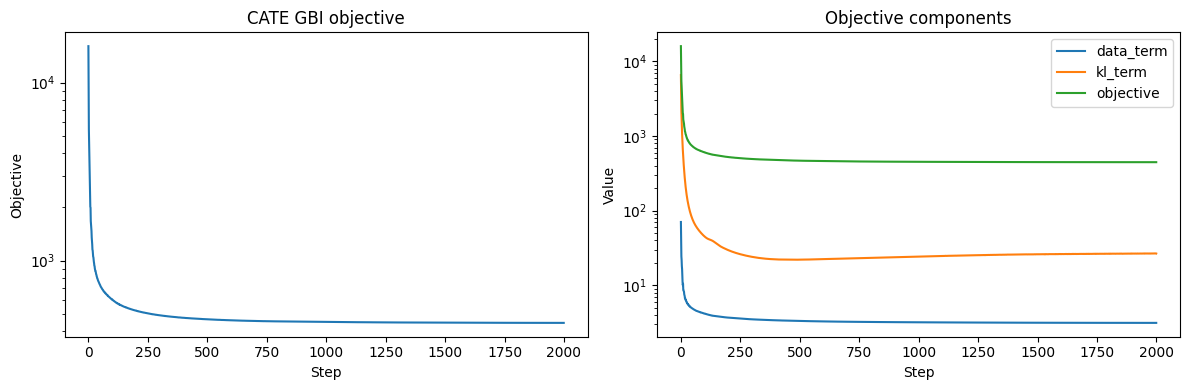

In [28]:

# GBI optimization diagnostics (CATE)
gbi_cate_diagnostics(history)


In [29]:

# Summary dump: collect key diagnostics into one block for copy/paste
import numpy as np

summary_lines = []
summary_lines.append('=== CATE diagnostic summary ===')

if 'experiment_id' in globals():
    summary_lines.append(f"experiment_id: {experiment_id}")
if 'run_id' in globals():
    summary_lines.append(f"run_id: {run_id}")
if 'run_cfg' in globals() and run_cfg is not None:
    summary_lines.append(f"Run config: {run_cfg.get('data'), run_cfg.get('loss', {}).get('phi_fn_REGISTRATION')}")

# Nuisance metrics (if available)
if all(name in globals() for name in ['e_hat', 'mu0_hat', 'mu1_hat', 'A', 'Y']):
    if e_hat is not None and mu0_hat is not None and mu1_hat is not None:
        a1 = e_hat[A == 1]
        a0 = e_hat[A == 0]
        if len(a1) > 0 and len(a0) > 0:
            auc_like = float(np.mean(a1[:, None] > a0[None, :]))
        else:
            auc_like = float('nan')
        mse0 = float(np.mean((Y[A == 0] - mu0_hat[A == 0]) ** 2)) if np.any(A == 0) else float('nan')
        mse1 = float(np.mean((Y[A == 1] - mu1_hat[A == 1]) ** 2)) if np.any(A == 1) else float('nan')
        def _r2(y_true, y_pred):
            ss_res = np.sum((y_true - y_pred) ** 2)
            ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
            if ss_tot == 0:
                return float('nan')
            return 1.0 - ss_res / ss_tot
        r2_0 = _r2(Y[A == 0], mu0_hat[A == 0]) if np.any(A == 0) else float('nan')
        r2_1 = _r2(Y[A == 1], mu1_hat[A == 1]) if np.any(A == 1) else float('nan')
        overlap = float(np.mean((e_hat > 0.05) & (e_hat < 0.95)))
        summary_lines.append(f"MSE(mu0): {mse0:.3f}, MSE(mu1): {mse1:.3f}")
        summary_lines.append(f"R2(mu0): {r2_0:.3f}, R2(mu1): {r2_1:.3f}")
        summary_lines.append(f"Propensity mean: {e_hat.mean():.3f}, std: {e_hat.std():.3f}, AUC~={auc_like:.3f}, overlap: {overlap:.3f}")

# Phi diagnostics
if 'phi' in globals() and phi is not None:
    summary_lines.append(f"phi mean: {float(np.mean(phi)):.4f}, phi std: {float(np.std(phi)):.4f}")

# CATE metrics
if 'cate_true' in globals() and cate_true is not None:
    if 'cate_mean_vi' in globals() and cate_mean_vi is not None:
        mse_vi = float(np.mean((cate_mean_vi - cate_true) ** 2))
        summary_lines.append(f"CATE MSE (VI): {mse_vi:.4f}")
    if 'cate_mean_analytic' in globals() and cate_mean_analytic is not None:
        mse_an = float(np.mean((cate_mean_analytic - cate_true) ** 2))
        summary_lines.append(f"CATE MSE (Analytic): {mse_an:.4f}")

# Analytic vs VI discrepancy
if 'cate_mean_vi' in globals() and 'cate_mean_analytic' in globals():
    if cate_mean_vi is not None and cate_mean_analytic is not None:
        diff = cate_mean_vi - cate_mean_analytic
        rmse = float(np.sqrt(np.mean(diff ** 2)))
        mae = float(np.mean(np.abs(diff)))
        summary_lines.append(f"Analytic vs VI: RMSE={rmse:.4f}, MAE={mae:.4f}")

# Tail vs middle MSE
if 'cate_X_eval' in globals() and cate_X_eval is not None and cate_true is not None:
    X_eval = np.asarray(cate_X_eval)
    if X_eval.ndim == 2 and X_eval.shape[1] >= 1:
        x0 = X_eval[:, 0]
        q_lo = np.quantile(x0, 0.1)
        q_hi = np.quantile(x0, 0.9)
        mask_tail = (x0 <= q_lo) | (x0 >= q_hi)
        mask_mid = (x0 > q_lo) & (x0 < q_hi)
        def _mse(pred):
            if pred is None:
                return np.nan, np.nan
            mse_tail = np.mean((pred[mask_tail] - cate_true[mask_tail]) ** 2)
            mse_mid = np.mean((pred[mask_mid] - cate_true[mask_mid]) ** 2)
            return mse_tail, mse_mid
        mse_tail_vi, mse_mid_vi = _mse(cate_mean_vi)
        mse_tail_an, mse_mid_an = _mse(cate_mean_analytic)
        summary_lines.append(f"MSE (VI) tails: {mse_tail_vi:.4f}, middle: {mse_mid_vi:.4f}")
        summary_lines.append(f"MSE (Analytic) tails: {mse_tail_an:.4f}, middle: {mse_mid_an:.4f}")

# Uncertainty summaries (if available)
if 'cate_var_vi' in globals() and cate_var_vi is not None:
    summary_lines.append(f"VI mean std: {float(np.mean(np.sqrt(np.maximum(cate_var_vi, 1e-12)))):.4f}")
if 'cate_var_analytic' in globals() and cate_var_analytic is not None:
    summary_lines.append(f"Analytic mean std: {float(np.mean(np.sqrt(np.maximum(cate_var_analytic, 1e-12)))):.4f}")

print("\n".join(summary_lines))


=== CATE diagnostic summary ===
experiment_id: exp1_backdoor_cate_attempt_1
run_id: run_84e62082b05c
Run config: ({'data_kind': 'backdoor_cate', 'dgp_fn_REGISTRATION': 'dgp_4', 'dgp_kwargs': {}, 'n': 1000}, 'aipw')
MSE(mu0): 0.918, MSE(mu1): 1.092
R2(mu0): 0.643, R2(mu1): 0.785
Propensity mean: 0.488, std: 0.176, AUC~=0.688, overlap: 0.994
phi mean: 0.9316, phi std: 2.7324
CATE MSE (VI): 0.1379
CATE MSE (Analytic): 0.0448
Analytic vs VI: RMSE=0.1632, MAE=0.1140
MSE (VI) tails: 0.3626, middle: 0.0817
MSE (Analytic) tails: 0.1308, middle: 0.0233
VI mean std: 0.4474
Analytic mean std: 0.3622
